## Dependencias

In [ ]:
# first of all install necessary packages
# wfdb usefull for reading ECG data
%pip install -U wfdb
# usefull for machine learning
%pip install -U scikit-learn tensorflow matplotlib pandas
# set matplotlib to plot in the notebook
%matplotlib inline

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.5.1-cp313-cp313-win_amd64.whl.metadata (46 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached cffi-2.1.1-cp313-cp313-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached charset_normalizer-3.5.1-cp313-cp313-win_amd64.whl (199 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 17.6 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 2.6 MB/s  0:00:00
Using cached cffi-2.1.1-cp313-cp313-win_amd64.whl (185 kB)
Using cached pycparser-3.0-py3-none-any.whl (48 kB)

   ----------------------------------------  0/17 [urllib3]
   ----------------------------------------  0/17 [urllib3]
   -----------

In [1]:
# Importar paquetes necesarios
import wfdb
from os.path import exists as file_exists
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
%matplotlib inline


In [2]:
from typing import Union,List, Tuple

# get signal with wfdb library
# using an index
def get_signal(index:int, as_p_signal:bool=True) -> Union[wfdb.Record, np.ndarray]:
    record = wfdb.rdrecord(DATA_FOLDER + "/" +  str(index))
    assert type(record) is wfdb.Record

    if as_p_signal:
        assert type(record.p_signal) is np.ndarray
        return record.p_signal
        
    return record

# get annotations given the ecg lead
def get_annotations(index:int, lead, as_sample=True) -> Union[wfdb.Annotation, np.ndarray]:
    annotations = wfdb.rdann(DATA_FOLDER +"/" + str(index), extension = lead)
    if as_sample:
        return np.array(annotations.sample)
    return annotations

# get a full EGC with 12 leads
def get_full_ecg(index:int):
    signal = get_signal(index)
    annotations = [
        get_annotations(index, lead) for lead in LEADS
    ]
    return signal, annotations


def get_single_lead_ecg(index, lead) -> Tuple[np.ndarray, np.ndarray]:
    """
    return and ecg signal and its annotations
    both as ndarray
    """
    signal = get_signal(index)
    assert type(signal) is np.ndarray
    signal = signal[:, LEADS.index(lead)]

    samples = get_annotations(index, lead)
    assert type(samples) is np.ndarray
    
    return signal, samples


def get_annotations_symbols(index, lead):
    ann = get_annotations(index, lead, as_sample=False)
    return ann.symbol

def paired_annotation_sample_and_symbol(index, lead):
    annotations_symbols = get_annotations_symbols(index, lead)
    annotations_sample = get_annotations(index, lead)
    return zip(annotations_sample, annotations_symbols)


def get_single_lead_ecg_with_symbols(index, lead):
    """
    return and ecg signal and its annotations
    both as ndarray
    """
    signal = get_signal(index)
    assert type(signal) is np.ndarray
    signal = signal[:, LEADS.index(lead)]

    data = paired_annotation_sample_and_symbol(index, lead)
    
    return signal, np.array(list(data))

# plot single lead ecg with annotations
def plot_single_lead_ecg(index, lead):
    signal, samples = get_single_lead_ecg(index, lead)

    fig, ax = plt.subplots(figsize = (35, 10))
    fig.tight_layout()
    fig.autofmt_xdate()
    ax.plot(signal)
    ax.scatter(samples, signal[samples], c = 'r', marker = 'o')


# now plot every lead with annotations
def plot_signal_with_annotation(index):
    signal, samples = get_full_ecg(index)
    # extract sample from annotations
    wfdb.plot_items(signal, samples )
    return signal, samples

## Seleccion de señal
Colocar en ID la señal para generar el archivo

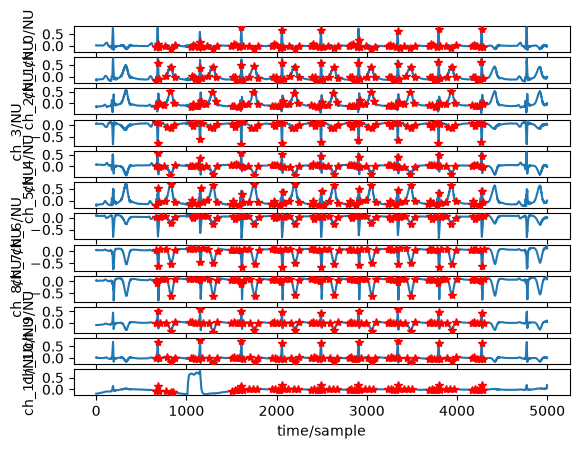

In [6]:
# Deteccion automatica de rutas base (funciona tanto desde la raiz del repo como desde datasets/scripts)
CWD = Path().resolve()
if (CWD / 'datasets' / 'raw').exists():
    DATASETS_DIR = CWD / 'datasets'
elif (CWD.parent / 'raw').exists():
    DATASETS_DIR = CWD.parent
else:
    DATASETS_DIR = Path('../').resolve()

DATA_FOLDER = str(DATASETS_DIR / 'raw' / 'lobachevsky-university-electrocardiography-database-1.0.1' / 'data')
OUTPUT_HEADER_DIR = DATASETS_DIR / 'header_arrays'
OUTPUT_HEADER_DIR.mkdir(parents=True, exist_ok=True)

LEADS = ['avf', 'avl', 'avr', 'i', 'ii', 'iii', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
ID = 64
signal, samples = plot_signal_with_annotation(index=ID)


## Seleccionar ciclo de la señal 
Se busca el ciclo en el cual el comienzo tiene la amplitud lo mas parecida al final, para reproducirse luego de forma cíclica

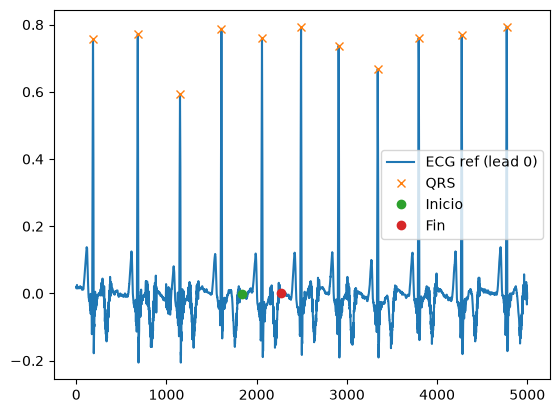

Mejor ciclo: 5
Init: 1834 End: 2275
Suma de diferencias: 0.07154944438148945


In [7]:
# Señales ECG en todas las columnas
X = signal

# Detectar QRS en la primera derivación (para definir los ciclos)
x_ref = X[:, 0]
peaks, _ = find_peaks(x_ref, distance=150, prominence=0.4)

best_cycle = None
best_diff = np.inf
best_init = None
best_end = None

# Iterar ciclos (misma lógica que antes)
for i in range(2, len(peaks)):
    init = int((peaks[i-1] - peaks[i-2]) / 2 + peaks[i-2])
    end  = int((peaks[i]   - peaks[i-1]) / 2 + peaks[i-1])

    # Calcular la diferencia en TODAS las derivaciones
    diffs = [abs(X[end, c] - X[init, c]) for c in range(X.shape[1])]
    total_diff = sum(diffs)

    if total_diff < best_diff:
        best_diff = total_diff
        best_cycle = i
        best_init = init
        best_end = end

# Visualizar con la derivación de referencia
plt.plot(x_ref, label="ECG ref (lead 0)")
plt.plot(peaks, x_ref[peaks], "x", label="QRS")
plt.plot(best_init, x_ref[best_init], "o", label="Inicio")
plt.plot(best_end, x_ref[best_end], "o", label="Fin")
plt.legend()
plt.show()

print("Mejor ciclo:", best_cycle)
print("Init:", best_init, "End:", best_end)
print("Suma de diferencias:", best_diff)

# Extraer todos los canales para ese ciclo
cycle_all = X[best_init:best_end+1, :]
end = (int)((peaks[best_cycle]-peaks[best_cycle-1])/2+peaks[best_cycle-1])
init = (int)((peaks[best_cycle-1]-peaks[best_cycle-2])/2+peaks[best_cycle-2])

Left anterior hemiblock
Sinus_rhythm
Filas:
441
Archivo 'Sinus_rhythm_N_65.h' generado exitosamente en D:\Documents\GitHub\ECG_Phantom\datasets\header_arrays.


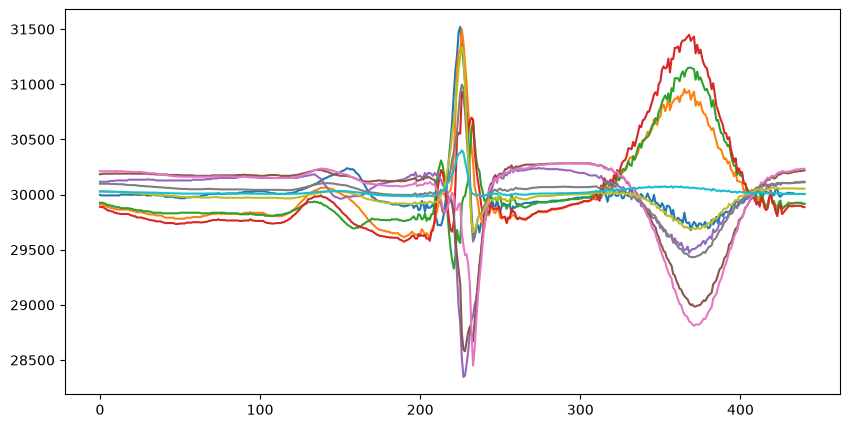

In [8]:
# Cargar el archivo CSV a un DataFrame de pandas
file_path = DATASETS_DIR / 'raw' / 'lobachevsky-university-electrocardiography-database-1.0.1' / 'ludb.csv'
df = pd.read_csv(file_path)
# Convertir el DataFrame a un arreglo de numpy
array = df.values
df = df.fillna('NONE')
print(df['Conduction abnormalities'][ID])

# String original
original_string = df['Rhythms'][ID]

# Reemplazar espacio por guion bajo
modified_string = original_string.replace(" ", "_")
print(modified_string) 

print("Filas:")
ROWS= end-init
print(ROWS)
COLS=12
init_sample = init
array = signal[:, list(range(0, 3)) + list(range(5, 12))]*2000+30000
array = array[init:end, :]
fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(array)

# Convert the array to integers
array_int = array.astype(int)

# Variables for file and array names, and dimensions
file_name = modified_string
rythm_name = df['Rhythms'][ID]
cond_abnormality_name = df['Conduction abnormalities'][ID]  
hypertrophies_name = ' '.join(df['Hypertrophies'][ID].split('\n')) 
ischemia = ' '.join(df['Ischemia'][ID] .split('\n'))
pacing = ' '.join(df['Cardiac pacing'][ID].split('\n'))# Obtener la lista de strings
iden = str(df['ID'][ID])
extra = ' '.join(df['Extrasystolies'][ID].split('\n'))

array_name = modified_string
rows = array_int.shape[0]
cols = array_int.shape[1]

# Convert the integer array to a string with the required C format
array_str = "{\n" + ",\n".join(["    {" + ", ".join(map(str, row)) + "}" for row in array_int]) + "\n}"

# Create the content of the .h file
h_content = f"""\
#ifndef {file_name.upper()}_N_{iden.upper()}_H
#define {file_name.upper()}_N_{iden.upper()}_H

#include "ecg_types.h"

#define ROWS_{iden.upper()} {rows}
#define COLS_{iden.upper()} {cols}

static const int ecg_array[ROWS_{iden.upper()}][COLS_{iden.upper()}] = {array_str};

ecg_struct_t {array_name}_N_{iden.upper()} = {{
    .rhythms[] = "{rythm_name.upper()}";
    .cond_abnor[]="{cond_abnormality_name.upper()}";
    .hypertrophies[]="{hypertrophies_name.upper()}";
    .ischemia[]="{ischemia.upper()}";
    .pacing[]="{pacing.upper()}";
    .extrasystolies[]="{extra.upper()}";
    .rows=rows;
    .cols=cols;
    .array=ecg_array; 
}};



#endif // {file_name.upper()}_N_{iden.upper()}_H
"""

# Guardar el contenido en la carpeta header_arrays
out_path = OUTPUT_HEADER_DIR / f"{file_name}_N_{iden.upper()}.h"
with open(out_path, "w") as f:
    f.write(h_content)

print(f"Archivo '{out_path.name}' generado exitosamente en {OUTPUT_HEADER_DIR}.")
